In [1]:
print("all ok")

all ok


In [2]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [3]:
model="openai/gpt-oss-120b"
from langchain_groq import ChatGroq
llm = ChatGroq(
    model_name=model,
    temperature=0
)
response=llm.invoke("what is length of wall of china?")

In [4]:
response

AIMessage(content='The Great Wall of China stretches for roughly **21,000\u202fkilometers (about 13,000\u202fmiles)** when you add together all of its main sections, branches, and ancillary walls that have been built over the centuries.  \n\n- **Official figure (2021‑2022 survey):** 21,196\u202fkm (13,171\u202fmi)  \n- **What’s included:** the main wall, secondary walls, trenches, natural barriers (like hills and rivers) that were incorporated into the defensive system, and the “Ming‑era” sections that are most often visited today.  \n\nBecause the wall was constructed, rebuilt, and extended by different dynasties over a span of more than 2,000\u202fyears, the total length varies depending on which sections are counted. The 21,000\u202fkm figure is the most comprehensive measurement currently accepted by Chinese authorities.', additional_kwargs={'reasoning_content': 'The user asks: "what is length of wall of china?" They want the length of the Great Wall of China. Provide answer. It\'s

In [5]:
response.content

'The Great Wall of China stretches for roughly **21,000\u202fkilometers (about 13,000\u202fmiles)** when you add together all of its main sections, branches, and ancillary walls that have been built over the centuries.  \n\n- **Official figure (2021‑2022 survey):** 21,196\u202fkm (13,171\u202fmi)  \n- **What’s included:** the main wall, secondary walls, trenches, natural barriers (like hills and rivers) that were incorporated into the defensive system, and the “Ming‑era” sections that are most often visited today.  \n\nBecause the wall was constructed, rebuilt, and extended by different dynasties over a span of more than 2,000\u202fyears, the total length varies depending on which sections are counted. The 21,000\u202fkm figure is the most comprehensive measurement currently accepted by Chinese authorities.'

In [6]:
from langchain.tools import tool

## this is my custom tools

In [7]:
from langchain.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """
    Multiply two integers.

    Args:
        a (int): The first integer.
        b (int): The second integer.

    Returns:
        int: The product of a and b.
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """
    Add two integers.

    Args:
        a (int): The first integer.
        b (int): The second integer.

    Returns:
        int: The sum of a and b.
    """
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """
    Divide two integers.

    Args:
        a (int): The numerator.
        b (int): The denominator (must not be 0).

    Returns:
        float: The result of division.
    """
    if b == 0:
        raise ValueError("Denominator cannot be zero.")
    return a / b

## importing the inbuilt tool

In [8]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19012\1490462257.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [9]:
search.invoke("what is the latest update on iphone17 release?")

'The latest iteration of the iPhone was revealed by Apple on Tuesday, Sept. 9. Here are the key new features, prices, and when you can order one. Apple has unveiled four new iPhones: the iPhone 17, iPhone Air, iPhone 17 Pro and iPhone 17 Pro Max. Here\'s the lowdown on the specs, price, new features, design, dimensions and more. See the full list of iPhones getting the iOS 27 update, which models get Siri AI, and what the beta and stable release dates look like. The update supports iPhone 11 and newer models, though premium AI features like new Siri voices require iPhone 17 Pro or later devices. Apple has unveiled the iPhone 17 during its "Awe Dropping" event, showcasing all the improvements, colors and more.'

In [ ]:
# !pip install duckduckgo_search


In [10]:
tools=[multiply, add, divide, search]

In [11]:
llm_with_tools=llm.bind_tools(tools)

In [12]:
response=llm_with_tools.invoke("hi")

In [13]:
response.content

'Hello! How can I help you today?'

In [14]:
response.tool_calls

[]

In [15]:
response=llm_with_tools.invoke("what is 2+2?")

In [16]:
response.content

''

In [17]:
response.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'fc_d5c9f8b7-cca4-4aa6-b9db-6be9698ed27c',
  'type': 'tool_call'}]

In [18]:
response=llm_with_tools.invoke("what is 10/2?")

In [19]:
response.content

'10 divided by\u202f2 equals **5**.'

In [20]:
response.tool_calls

[]

In [21]:
response=llm_with_tools.invoke("what is a current age of the TATA Group?")

In [22]:
response

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is a current age of the TATA Group?" They want the age (how many years since founding). Need current info. Likely need to search. Use duckduckgo_search.', 'tool_calls': [{'id': 'fc_ce8db143-4df6-439f-a995-a0a81a3dd6cf', 'function': {'arguments': '{"query":"Tata Group founded year"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 336, 'total_tokens': 414, 'completion_time': 0.160583428, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.014597005, 'prompt_tokens_details': None, 'queue_time': 0.279437792, 'total_time': 0.175180433}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e5b4e54fbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f09fb-fe85-7832-9dcc-213284a94a9a-0', tool_calls=[{'name': 'duckduckgo_search'

In [23]:
response.content

''

In [24]:
response.tool_calls

[{'name': 'duckduckgo_search',
  'args': {'query': 'Tata Group founded year'},
  'id': 'fc_ce8db143-4df6-439f-a995-a0a81a3dd6cf',
  'type': 'tool_call'}]

In [25]:
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [26]:
SYSTEM_PROMPT="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs."



In [27]:
user_query=["tell me what is 2+2"]

In [28]:
[SYSTEM_PROMPT]+user_query

['You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.',
 'tell me what is 2+2']

In [29]:
def function_1(state:MessagesState):
    
    user_question=state["messages"]
    
    input_question = [SYSTEM_PROMPT]+user_question
    
    response = llm_with_tools.invoke(input_question)
    
    return {
        "messages":[response]
    }
    
    

In [30]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START

In [31]:
builder=StateGraph(MessagesState)

In [32]:
builder.add_node("llm_decision_step",function_1)

In [33]:
tools

[StructuredTool(name='multiply', description='Multiply two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The product of a and b.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000027609566AE0>),
 StructuredTool(name='add', description='Add two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The sum of a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x0000027609E32980>),
 StructuredTool(name='divide', description='Divide two integers.\n\nArgs:\n    a (int): The numerator.\n    b (int): The denominator (must not be 0).\n\nReturns:\n    float: The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x00000276093D83B0>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', 

In [34]:
from langgraph.prebuilt import ToolNode
builder.add_node("tools",ToolNode(tools))

In [35]:
builder.add_edge(START,"llm_decision_step")

In [36]:
from langgraph.prebuilt import tools_condition
builder.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)


In [37]:
builder.add_edge("tools","llm_decision_step")

In [38]:
react_graph=builder.compile()

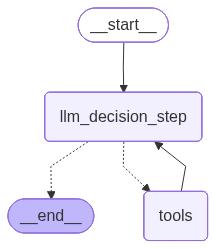

In [39]:
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [40]:
message=[HumanMessage(content="What is 2 times of narendramodi's age?")]

In [41]:
react_graph.invoke({"messages":message})

{'messages': [HumanMessage(content="What is 2 times of narendramodi's age?", additional_kwargs={}, response_metadata={}, id='fc7d6374-f6f3-425e-acb8-b84ff67b4b12'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is 2 times of narendramodi\'s age?" Need to find Narendra Modi\'s age, then multiply by 2. Must use search to get current age (as of now, date 2026-06-27). Narendra Modi born 17 September 1950. As of 27 June 2026, his age is 75 (will turn 76 on Sep 17 2026). So age = 75. Multiply by 2 = 150. Need to verify via search. Use duckduckgo search for "Narendra Modi age".', 'tool_calls': [{'id': 'fc_6d522969-0e9c-4b42-9e58-1a235cb5de3a', 'function': {'arguments': '{"query":"Narendra Modi age"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 156, 'prompt_tokens': 360, 'total_tokens': 516, 'completion_time': 0.335167316, 'completion_tokens_details': {'reasoning_tokens': 123}, 'prompt_tim

In [42]:
message = [HumanMessage(content="How much is the net worth of Elon Musk, and divide it by 2?")]

In [43]:
react_graph.invoke({"messages":message})

{'messages': [HumanMessage(content='How much is the net worth of Elon Musk, and divide it by 2?', additional_kwargs={}, response_metadata={}, id='c2174fd7-32c8-46b9-8ee0-bde13737c6c8'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to find net worth of Elon Musk (current). Must use search. Then divide by 2 using arithmetic function. Use duckduckgo_search.', 'tool_calls': [{'id': 'fc_22f0efed-1b7d-4cad-b6ac-740ea6f1b581', 'function': {'arguments': '{"query":"Elon Musk net worth 2024"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 364, 'total_tokens': 433, 'completion_time': 0.144392699, 'completion_tokens_details': {'reasoning_tokens': 32}, 'prompt_time': 0.014781063, 'prompt_tokens_details': None, 'queue_time': 0.286101744, 'total_time': 0.159173762}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_49bfac06f1', 'service_tier': 'on_demand', 'finish_reason': 'to

In [44]:
message = [HumanMessage(content="What is the speed of light in m/s and multiply it by 10?")]

In [45]:
response=react_graph.invoke({"messages":message})

In [46]:
response["messages"][-1].content

'The speed of light in a vacuum is **299,792,458\u202fm/s**.  \n\nMultiplying that by 10 gives:\n\n**2,997,924,580\u202fm/s**.'

In [47]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the speed of light in m/s and multiply it by 10?
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_251afbec-fab8-49f6-ad08-171045358352)
 Call ID: fc_251afbec-fab8-49f6-ad08-171045358352
  Args:
    a: 299792458
    b: 10
================================= Tool Message =================================
Name: multiply

2997924580
================================== Ai Message ==================================

The speed of light in a vacuum is **299,792,458 m/s**.  

Multiplying that by 10 gives:

**2,997,924,580 m/s**.


In [48]:
import yfinance as yf

In [49]:
@tool
def get_stock_price(ticker:str)->str:
    """
    Fetches the previous closing price of a given stock ticker from Yahoo Finance.

    Args:
        ticker (str): The stock ticker symbol (e.g., 'AAPL', 'TSLA', 'NIFTY.BO').

    Returns:
        str: A message with the stock's previous closing price.
    """
    try:
        stock = yf.Ticker(ticker)
        price = stock.info.get('previousClose')
        if price is None:
            return f"Could not fetch price for ticker '{ticker}'."
        return f"The last closing price of {ticker.upper()} was ${price:.2f}."
    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"
     
    

In [50]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $275.15.'

In [51]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $375.12.'

In [52]:
tools

[StructuredTool(name='multiply', description='Multiply two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The product of a and b.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000027609566AE0>),
 StructuredTool(name='add', description='Add two integers.\n\nArgs:\n    a (int): The first integer.\n    b (int): The second integer.\n\nReturns:\n    int: The sum of a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x0000027609E32980>),
 StructuredTool(name='divide', description='Divide two integers.\n\nArgs:\n    a (int): The numerator.\n    b (int): The denominator (must not be 0).\n\nReturns:\n    float: The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x00000276093D83B0>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', 

In [53]:
tools = [add, multiply, divide, search,get_stock_price]

In [54]:
llm_with_tools=llm.bind_tools(tools)

In [55]:
response=llm_with_tools.invoke("can you give me a latest stock price of adani greens?")

In [56]:
response.content

''

In [57]:
response.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'ADANIGREEN.NS'},
  'id': 'fc_1c3d09d2-a21a-487a-a3c8-45d6d2fe2c39',
  'type': 'tool_call'}]

In [58]:
SYSTEM_PROMPT = SystemMessage(
    content="You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on a set of inputs."
)
def function_1(state:MessagesState):
    
    user_question=state["messages"]
    
    input_question = [SYSTEM_PROMPT]+user_question
    
    response = llm_with_tools.invoke(input_question)
    
    return {
        "messages":[response]
    }

In [59]:
workflow = StateGraph(MessagesState)
workflow.add_node("llm_decision_step", function_1)
workflow.add_node("tools", ToolNode(tools))
workflow.add_edge(START, "llm_decision_step")
workflow.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)
workflow.add_edge("tools", "llm_decision_step")
react_graph2 = workflow.compile()

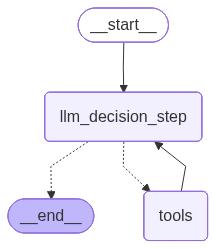

In [60]:
display(Image(react_graph2.get_graph(xray=True).draw_mermaid_png()))

In [63]:
messages = [HumanMessage(content="can you give me 2 times of current stock price of Apple with the latest news of the Apple.")]
messages = react_graph2.invoke({"messages": messages})

BadRequestError: Error code: 400 - {'error': {'message': 'Tool call validation failed: tool call validation failed: parameters for tool multiply did not match schema: errors: [`/a`: expected integer, but got number]', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '{"name": "multiply", "arguments": {\n  "a": 275.15,\n  "b": 2\n}}'}}

In [70]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

can you give me 2 times of current stock price of Apple with the latest news of the Apple.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (z83y9ab48)
 Call ID: z83y9ab48
  Args:
    ticker: AAPL
  duckduckgo_search (73vqrqtgj)
 Call ID: 73vqrqtgj
  Args:
    query: Apple latest news
================================= Tool Message =================================
Name: get_stock_price

The last closing price of AAPL was $259.58.
================================= Tool Message =================================
Name: duckduckgo_search

No good DuckDuckGo Search Result was found
================================== Ai Message ==================================

The last closing price of AAPL was $259.58. Unfortunately, I was unable to retrieve the latest news about Apple.
